In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [45]:
data = {
    'Area_sqft': [850, 900, 1200, 1500, 10000, 1300, 850, 1600], 
    'Bedrooms': [2, 2, 3, 3, 15, 3, 2, 4], 
    'Furnishing': ['Unfurnished', 'Semi', 'Fully', 'Semi', 'Fully', np.nan, 'Unfurnished', 'Fully'], 
    'Price_Lakhs': [45, 50, 65, 80, 500, 70, 40, 85]
}
df = pd.DataFrame(data)
df

,Area_sqft,Bedrooms,Furnishing,Price_Lakhs
0,850,2,Unfurnished,45
1,900,2,Semi,50
2,1200,3,Fully,65
3,1500,3,Semi,80
4,10000,15,Fully,500
5,1300,3,NaN,70
6,850,2,Unfurnished,40
7,1600,4,Fully,85


# EDA

<Axes: ylabel='Area_sqft'>

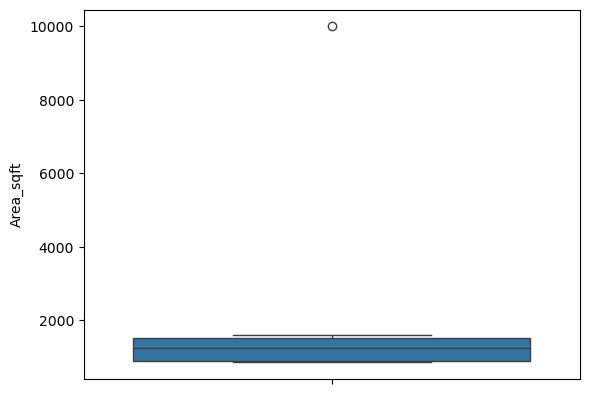

In [46]:
sns.boxplot(df['Area_sqft'])

In [47]:
# WE CAN CLEARLY SEE THAT THERE IS ONE OUTLIER IN OUR AREA_SQFT COLUMN 

In [48]:
df = df.drop(4)

In [49]:
df

,Area_sqft,Bedrooms,Furnishing,Price_Lakhs
0,850,2,Unfurnished,45
1,900,2,Semi,50
2,1200,3,Fully,65
3,1500,3,Semi,80
5,1300,3,NaN,70
6,850,2,Unfurnished,40
7,1600,4,Fully,85


In [50]:
print(df.isna())

   Area_sqft  Bedrooms  Furnishing  Price_Lakhs
0      False     False       False        False
1      False     False       False        False
2      False     False       False        False
3      False     False       False        False
5      False     False        True        False
6      False     False       False        False
7      False     False       False        False


In [59]:
df['Furnishing'] = df['Furnishing'].fillna(df['Furnishing'].mode().iloc[0])

""" The mode value df['Furnishing'].mode() returns a Series where the mode value is at index 0,
pandas only looks to fill a missing value at index 0 of your dataframe. Index 5 gets completely ignored, leaving it as NaN."""

" The mode value df['Furnishing'].mode() returns a Series where the mode value is at index 0,\npandas only looks to fill a missing value at index 0 of your dataframe. Index 5 gets completely ignored, leaving it as NaN."

In [156]:
df

,Area_sqft,Bedrooms,Furnishing,Price_Lakhs
0,850,2,2,45
1,900,2,1,50
2,1200,3,0,65
3,1500,3,1,80
5,1300,3,0,70
6,850,2,2,40
7,1600,4,0,85


In [157]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Furnishing'] = le.fit_transform(df['Furnishing'])
print(le.classes_)
df

[0 1 2]


,Area_sqft,Bedrooms,Furnishing,Price_Lakhs
0,850,2,2,45
1,900,2,1,50
2,1200,3,0,65
3,1500,3,1,80
5,1300,3,0,70
6,850,2,2,40
7,1600,4,0,85


In [158]:
# Phase 2
from sklearn.model_selection import train_test_split

In [159]:
X = df[['Area_sqft']]  
y = df[['Price_Lakhs']]

In [160]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [161]:
from sklearn.linear_model import LinearRegression

In [162]:
model = LinearRegression()

In [163]:
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [164]:
y_pred = model.predict(X_test)

In [165]:
y_test

,Price_Lakhs
0,45
1,50


In [166]:
y_pred

array([[41.75438596],
       [44.73684211]])

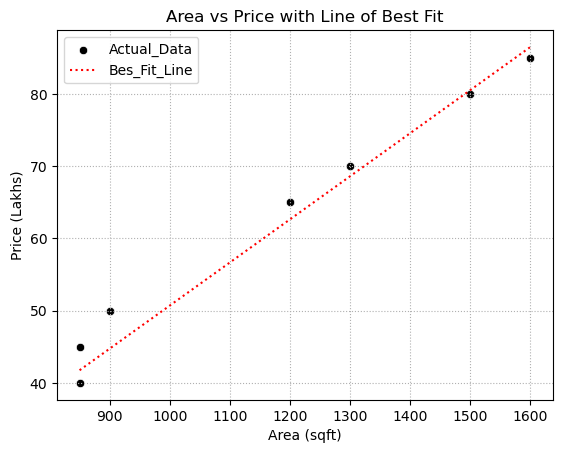

In [167]:
sns.scatterplot( x = df['Area_sqft'] , y = df['Price_Lakhs'] , label = 'Actual_Data' , color = 'black')
X_line = np.linspace(df[['Area_sqft']].min() , df[['Area_sqft']].max() , 100)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color='red', linestyle = ':' , label='Bes_Fit_Line')

plt.xlabel('Area (sqft)')
plt.ylabel('Price (Lakhs)')
plt.title('Area vs Price with Line of Best Fit')
plt.legend()
plt.grid(True, linestyle=':', )
plt.show()

In [171]:
y = df['Price_Lakhs']
X = df.drop('Price_Lakhs' , axis = 1) 

In [173]:
# Phase 3
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train , y_train)

theoretical_property = [[1400, 3, 2]] # This is a 2-D array 
predicted_valuation = model.predict(theoretical_property)

print(f"Theoretical Property: 1400 sq. ft, 3 BHK, Fully Furnished")
print(f"Predicted Market Value: {predicted_valuation[0]} Lakhs")


Theoretical Property: 1400 sq. ft, 3 BHK, Fully Furnished
Predicted Market Value: 70.20676691729324 Lakhs
